# Import Libraries

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df = pd.read_csv("Processed_Flipdata.csv")

In [3]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


# Remove Unwanted Column

In [5]:
if "Unnamed: 0" in df.columns: df.drop("Unnamed: 0", axis=1, inplace=True)

# Clean Column Names

In [6]:
df.columns = df.columns.str.replace("_", "")

df.columns = df.columns.str.strip()

# Handle Duplicates

In [7]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After removing duplicates:", df.duplicated().sum())

Duplicates: 10
After removing duplicates: 0


# Clean Price Column

In [8]:
df["Prize"] = df["Prize"].astype(str)
df["Prize"] = df["Prize"].str.replace(",", "")
df["Prize"] = df["Prize"].str.replace(" ", "")
df["Prize"] = df["Prize"].astype(float)

# Handle Missing Values

In [9]:
print(df.isnull().sum())

Model            0
Colour           0
Memory           0
RAM              0
Battery          0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor        0
Prize            0
dtype: int64


# Outlier Detection

In [10]:
Q1 = df["Prize"].quantile(0.25)
Q3 = df["Prize"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: -5587.75
Upper Limit: 34294.25


In [11]:
outliers = df[(df["Prize"] < lower) | (df["Prize"] > upper)]
print("Total Outliers:", len(outliers))

Total Outliers: 25


In [12]:
print(df[df["Prize"] > upper].head())

                          Model         Colour  Memory  RAM  Battery  \
222  SAMSUNG Galaxy S22 Plus 5G  Phantom Black     128    8     4500   
286   SAMSUNG Galaxy Z Flip3 5G  Phantom Black     128    8     3300   
305     MOTOROLA Edge 30 Fusion    Cosmic grey     128    8     4400   
308             Google Pixel 7a            Sea     128    8     4300   
309             Google Pixel 7a       Charcoal     128    8     4300   

    Rear Camera Front Camera  AI Lens  Mobile Height  \
222        50MP         10MP        0          16.76   
286        12MP         10MP        0          17.02   
305        50MP         32MP        0          16.64   
308        64MP         13MP        0          15.49   
309        64MP         13MP        0          15.49   

                             Processor    Prize  
222        Qualcomm Snapdragon 8 Gen 1  49999.0  
286  Qualcomm Snapdragon 888 Octa-Core  44999.0  
305          Qualcomm Snapdragon 888 +  34999.0  
308                          T

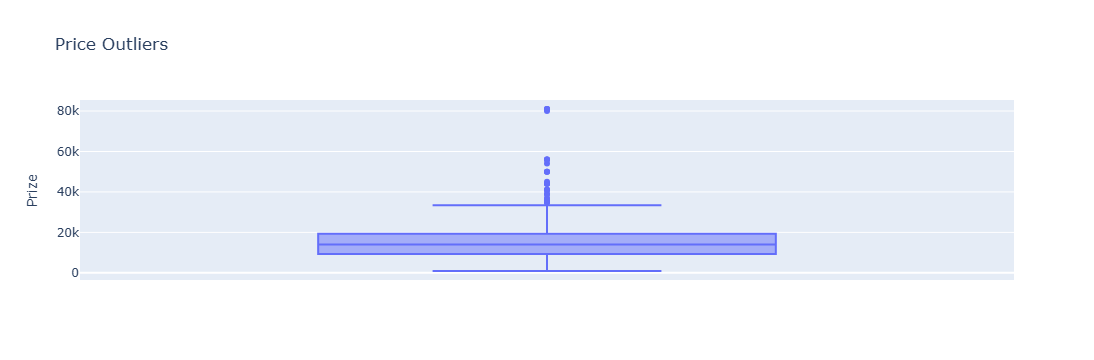

In [13]:
fig = px.box(df, y="Prize", title="Price Outliers")
fig.show()

# Outliers exist but represent real Premium devices so not removed

# Univariate Analysis

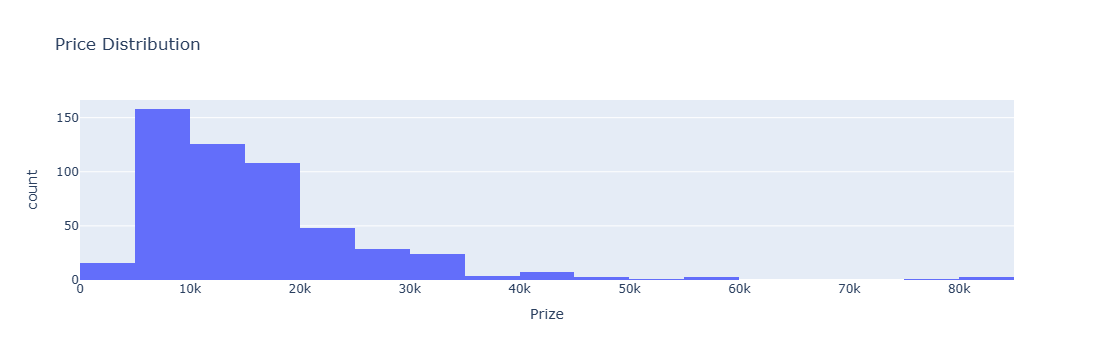

In [14]:
fig = px.histogram(df, x="Prize", nbins=30, title="Price Distribution")
fig.show()

# Most phones fall in mid price range

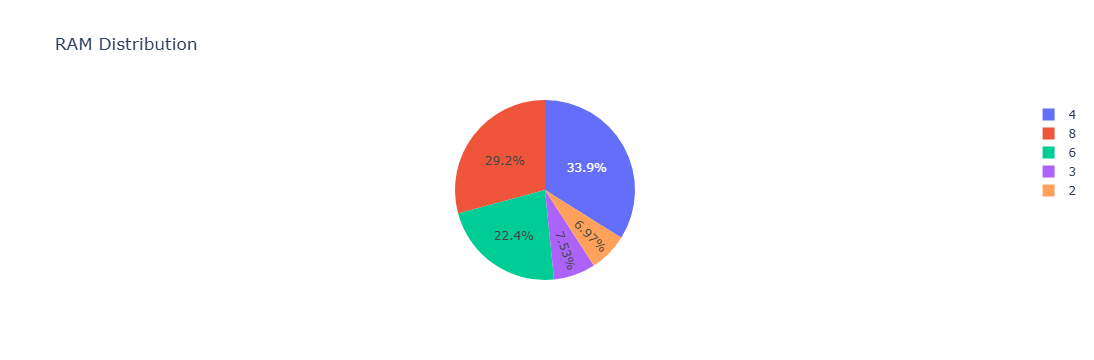

In [15]:
ram_count = df["RAM"].value_counts().reset_index()
ram_count.columns = ["RAM", "count"]

fig = px.pie(ram_count, names="RAM", values="count", title="RAM Distribution")
fig.show()

# Most phones have common RAM configuration

# Bivariate Analysis

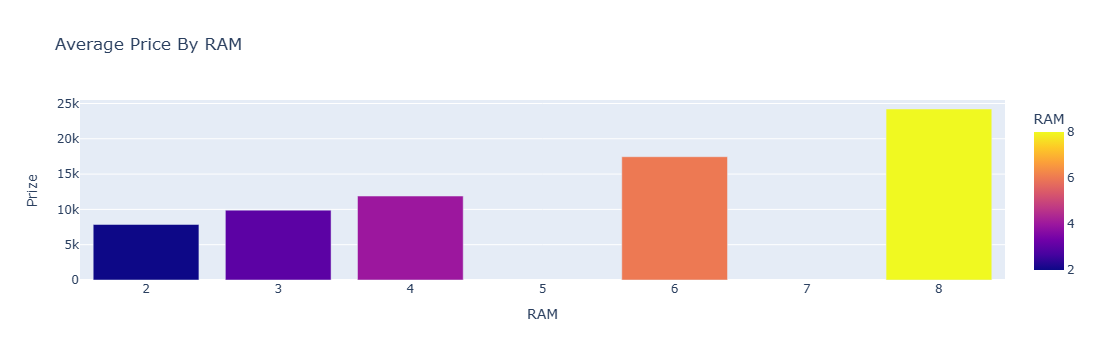

In [16]:
ram_avg = df.groupby("RAM")["Prize"].mean().reset_index()

fig = px.bar(ram_avg, x="RAM", y="Prize", color="RAM", title="Average Price By RAM")
fig.show()

# Higher RAM leads to higher avarage price

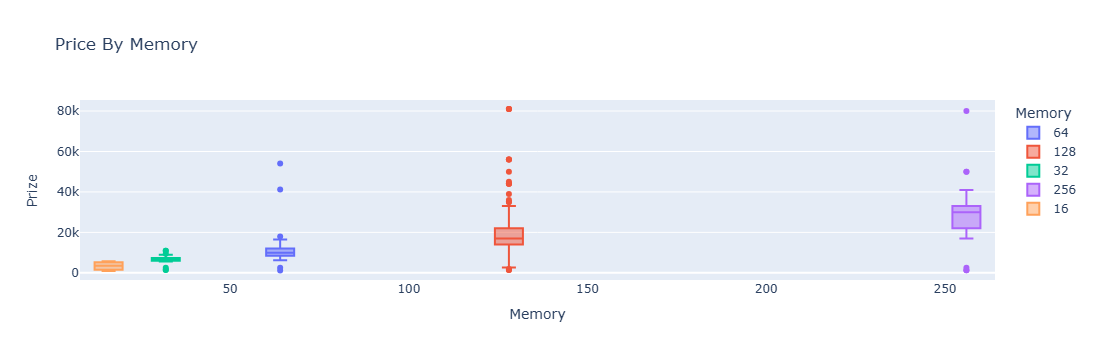

In [17]:
fig = px.box(df, x="Memory", y="Prize", color="Memory", title="Price By Memory")
fig.show()

# Higher memory increases price range

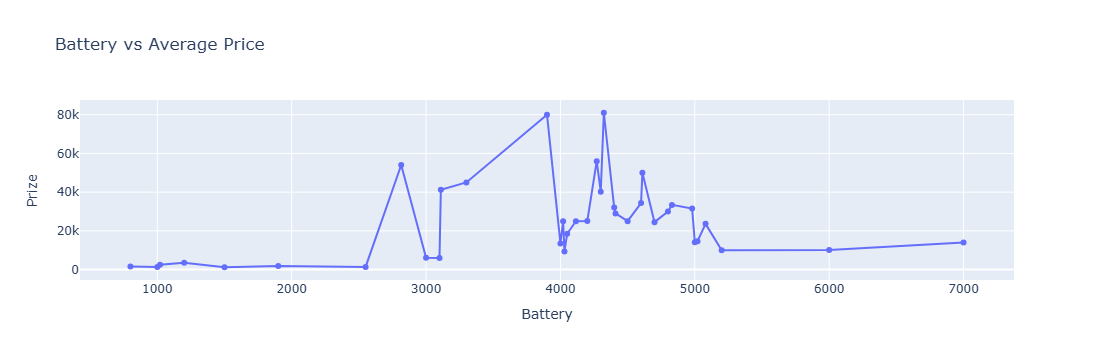

In [18]:
battery_avg = df.groupby("Battery")["Prize"].mean().reset_index()

fig = px.line(battery_avg, x="Battery", y="Prize", markers=True, title="Battery vs Average Price")
fig.show()

# Battery has weak influence on price

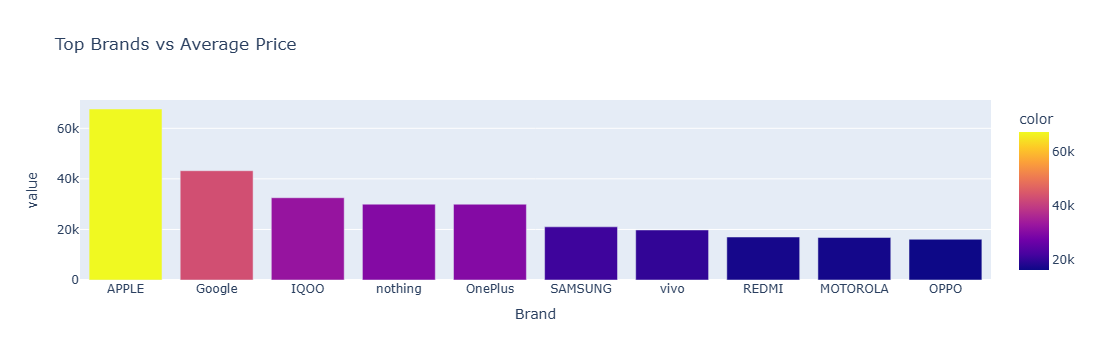

In [19]:
df["Brand"] = df["Model"].str.split().str[0]

brand_avg = df.groupby("Brand")["Prize"].mean().sort_values(ascending=False).head(10)

fig = px.bar(brand_avg,
             title="Top Brands vs Average Price",
             color=brand_avg.values)

fig.show()

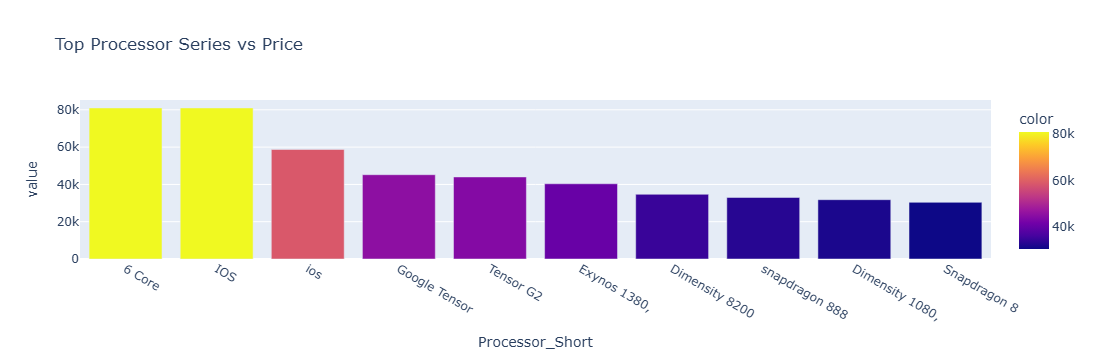

In [20]:
df["Processor_Short"] = df["Processor"].str.split().str[:2].str.join(" ")

proc_avg = df.groupby("Processor_Short")["Prize"].mean().sort_values(ascending=False).head(10)

fig = px.bar(proc_avg,
             title="Top Processor Series vs Price",
             color=proc_avg.values)

fig.show()

# Multivariate Analysis

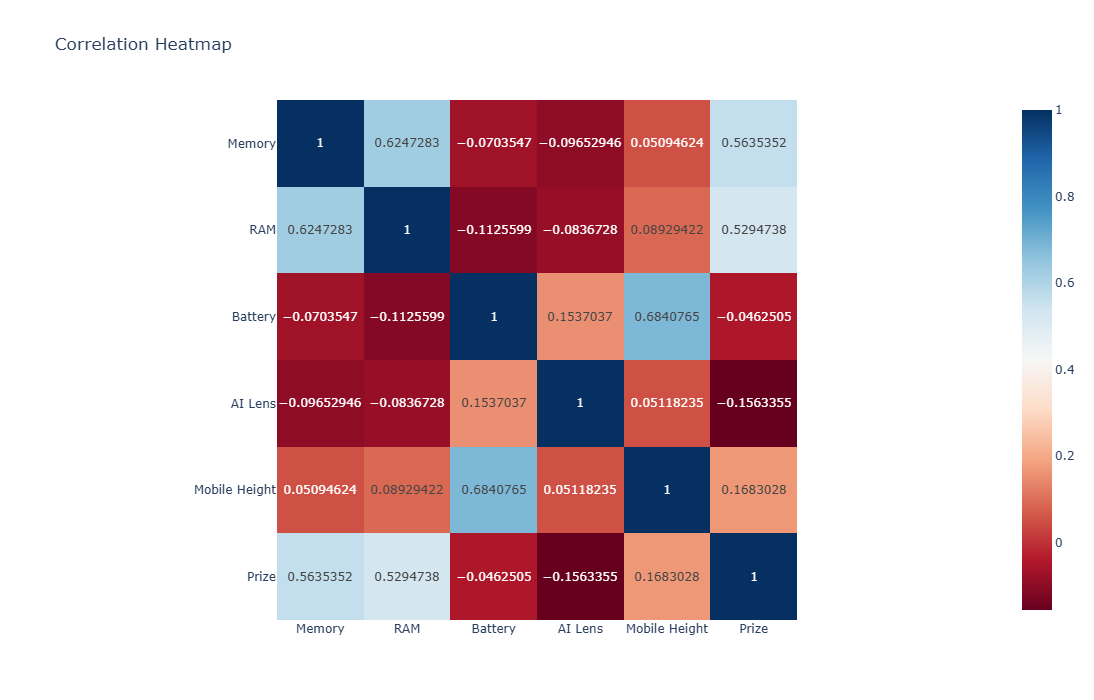

In [21]:
corr = df.corr(numeric_only=True)

fig = px.imshow(corr, text_auto=True, color_continuous_scale="RdBu", title="Correlation Heatmap")
fig.update_layout(width=900, height=700)
fig.show()

# RAM & memory show strong correlation with price

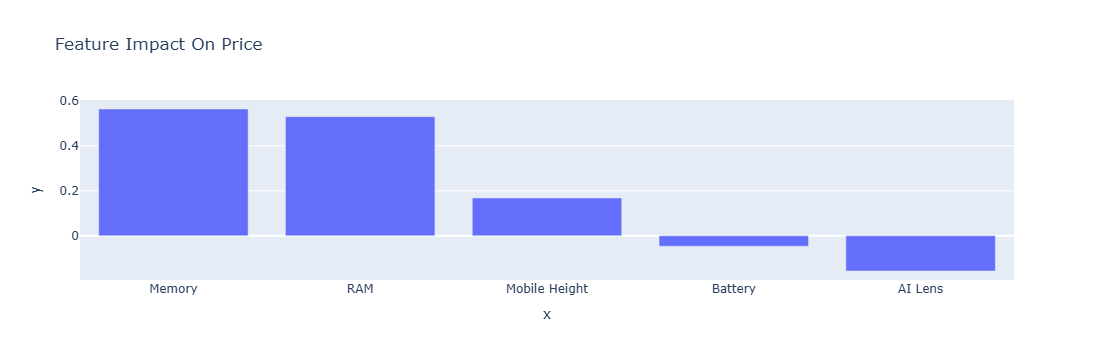

In [22]:
price_corr = corr["Prize"].drop("Prize").sort_values(ascending=False)

fig = px.bar(x=price_corr.index, y=price_corr.values, title="Feature Impact On Price")
fig.show()

# RAM & memory are most important features

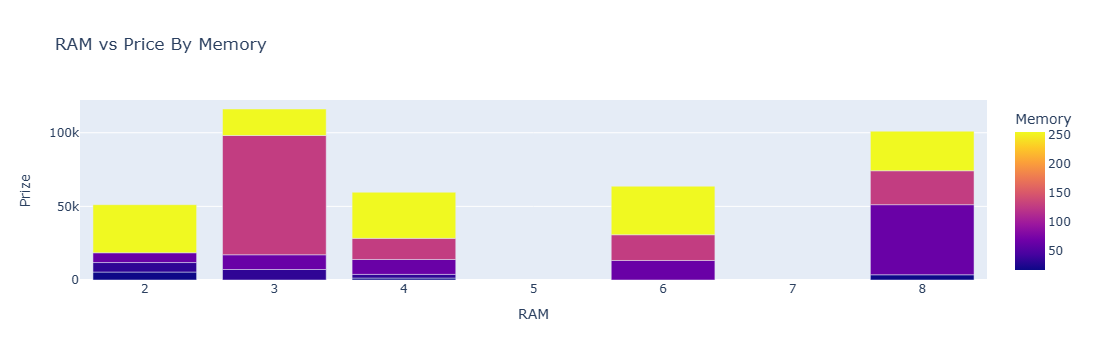

In [23]:
group = df.groupby(["RAM", "Memory"])["Prize"].mean().reset_index()

fig = px.bar(group, x="RAM", y="Prize", color="Memory", title="RAM vs Price By Memory")
fig.show()

# Same RAM with higher memory leads to higher price

# Final Conclusion

In [24]:
# RAM & memory are the most important factors affecting price
# Battery has minimal influence
# outliers represent premium devices and were not removed